In [2]:
# from google.colab import drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Devnagari Handwritten Digit Classification

##Data preparation

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test"

IMG_SIZE = (28, 28)
NUM_CLASSES = 10

In [3]:
def load_images(folder):
    """Load images from folder, resize, normalize, and extract labels."""

    # this function is basically handling the full data pipeline from folder → model-ready format
    images, labels = [], []  # storing image data and corresponding labels

    class_names = sorted(os.listdir(folder))
    # reading all class folders and sorting them
    # sorting is important so label assignment remains consistent every time

    class_map = {name: i for i, name in enumerate(class_names)}
    # mapping each class name to a numeric label
    # models understand numbers, not folder names

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue
        # safety check to skip any non-folder items

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                # converting to grayscale to reduce complexity
                # less data, faster training, and enough for many tasks

                img = img.resize(IMG_SIZE)
                # resizing all images to same shape (28x28)
                # consistency is required for neural networks

                img_array = np.array(img) / 255.0
                # normalizing pixel values from 0–255 to 0–1
                # helps with stable and faster training

                images.append(img_array)
                labels.append(class_map[class_name])
                # storing processed image and its label

            except Exception:
                pass
                # ignoring any unreadable or corrupted files
                # might improve later by logging skipped files

    return np.array(images), np.array(labels)
    # converting lists to numpy arrays for model compatibility


# Load data
x_train_raw, y_train_raw = load_images(train_dir)
x_test_raw,  y_test_raw  = load_images(test_dir)
# loading both training and testing datasets using same preprocessing


# Flatten 28x28 → 784 for FCN input
x_train = x_train_raw.reshape(-1, 28 * 28)
x_test  = x_test_raw.reshape(-1, 28 * 28)
# flattening 2D images into 1D vectors
# required because fully connected networks expect vector inputs


# One-hot encode labels
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)
# converting labels into one-hot format
# necessary for multi-class classification tasks


print(f"Train: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test : {x_test.shape},  Labels: {y_test.shape}")
# verifying shapes to ensure everything is correctly processed before training

Train: (17000, 784), Labels: (17000, 10)
Test : (3000, 784),  Labels: (3000, 10)


#Visualize

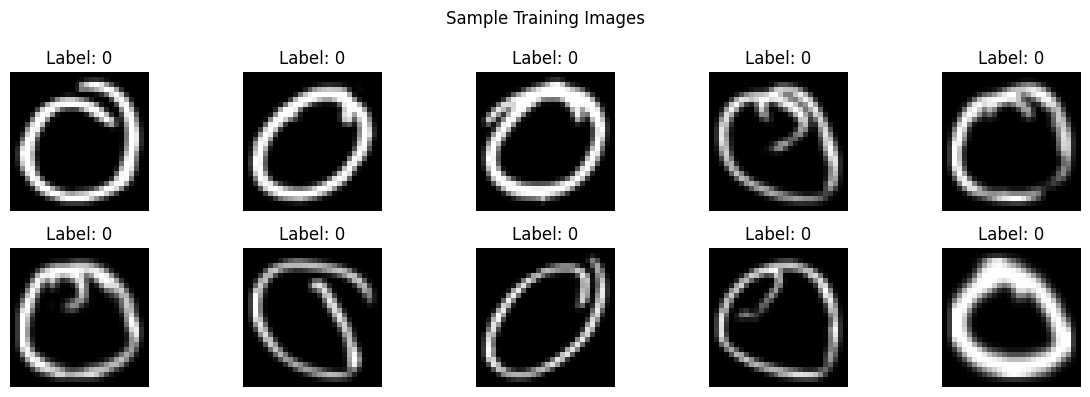

In [4]:
# Visualise sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

#FCN MODEL BUILDING

In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    # input layer → flattened image (28x28 = 784)

    keras.layers.Dense(64, activation='sigmoid'),
    # first hidden layer → starting small to capture basic patterns

    keras.layers.Dense(128, activation='sigmoid'),
    # increasing neurons → trying to learn more complex features

    keras.layers.Dense(256, activation='sigmoid'),
    # deeper layer → giving model more capacity

    keras.layers.Dense(NUM_CLASSES, activation='softmax')
    # output layer → probability distribution over classes
])

model.summary()
# quick check of architecture and parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
##Model compilation

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##MOdel training

In [8]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # saving only the best model based on validation accuracy

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1
    )
    # stops training if validation loss doesn't improve for 4 epochs
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    # processing 128 samples at a time

    epochs=20,
    # max training cycles (may stop early due to EarlyStopping)

    validation_split=0.2,
    # using 20% of training data for validation

    callbacks=callbacks,
    verbose=1
)
# training starts here and history will store performance over epochs

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2892 - loss: 1.9901
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5057 - loss: 1.6140 - val_accuracy: 0.0000e+00 - val_loss: 7.2602
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8131 - loss: 0.5994
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8480 - loss: 0.4836 - val_accuracy: 0.0000e+00 - val_loss: 8.2511
Epoch 3/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9149 - loss: 0.2903
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9226 - loss: 0.2658 - val_accuracy: 0.0000e+00 - val_loss: 8.8521
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9467 - loss: 0.1927
Epoch 4: val_accuracy did not imp

#Model Performance Analysis (Loss & Accuracy Curves)

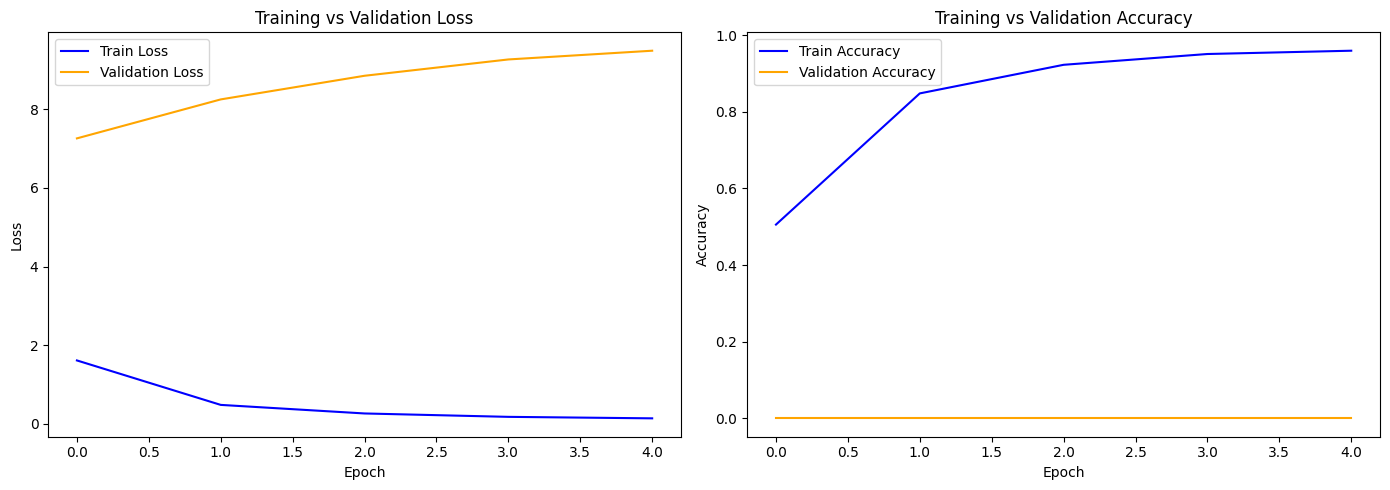

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# creating two plots side by side → one for loss, one for accuracy

# Losses
axes[0].plot(history.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
# comparing training vs validation loss to check learning behavior

axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# accuracy curve
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
# seeing how well model is performing on both train and validation

axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
# adjusting spacing so plots don’t overlap

plt.show()
# final visualization

In [10]:
##Evaluation of model

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
# evaluating model on unseen test data to check real performance

print(f"\nTest Loss    : {test_loss:.4f}")
# how much error model is making on test data

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
# final accuracy in both decimal and percentage form

94/94 - 0s - 4ms/step - accuracy: 0.7647 - loss: 2.0137

Test Loss    : 2.0137
Test Accuracy: 0.7647 (76.47%)


Model Saving and Reloading for Verification

In [13]:
# Save model
model.save('devnagari_fcn_model.h5')
# storing trained model so it can be reused later without retraining

print("Model saved → devnagari_fcn_model.h5")
# confirmation that model is successfully saved


# Load model and re-evaluate
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
# loading saved model back into memory

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
# checking if loaded model performs same as original model

print(f"\nLoaded Model — Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")
# final verification of saved model performance

Model saved → devnagari_fcn_model.h5
94/94 - 1s - 9ms/step - accuracy: 0.7647 - loss: 2.0137

Loaded Model — Test Loss: 2.0137, Test Accuracy: 0.7647


##further prediction s

In [14]:
# Predict on test set
predictions = loaded_model.predict(x_test)
# getting probability scores for each class

predicted_labels = np.argmax(predictions, axis=1)
# converting probabilities → final predicted class

true_labels = np.argmax(y_test, axis=1)
# converting one-hot encoded labels back to original form

print(f"Predicted: {predicted_labels[:10]}")
# showing first 10 predicted outputs for quick sanity check

print(f"True     : {true_labels[:10]}")
# comparing with actual labels to see how model is behaving

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
True     : [0 0 0 0 0 0 0 0 0 0]


Visual Inspection of Model Predictions

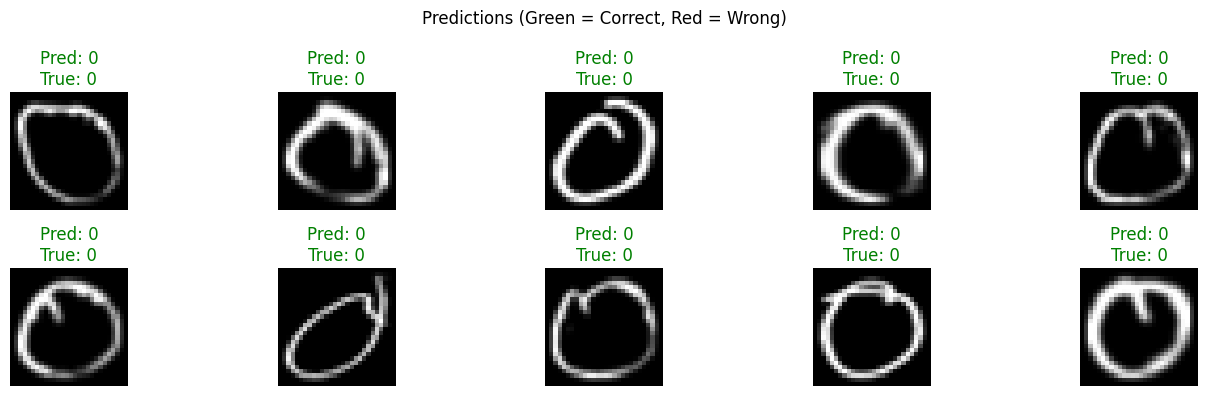

In [15]:
# Visualise predictions on 10 test samples
plt.figure(figsize=(14, 4))
# setting canvas size for better readability

for i in range(10):
    plt.subplot(2, 5, i + 1)
    # arranging images in grid (2 rows, 5 columns)

    plt.imshow(x_test_raw[i], cmap='gray')
    # displaying original test image

    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    # green = correct prediction, red = wrong prediction

    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}", color=color)
    # showing predicted vs actual label

    plt.axis('off')
    # removing axis for cleaner look

plt.suptitle("Predictions (Green = Correct, Red = Wrong)")
# overall heading for full visualization

plt.tight_layout()
plt.show()
# final display of prediction results